In [194]:
import torch
import open3d as o3d
import numpy as np
from tqdm import tqdm
import pickle
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
import torch.nn as nn
import torch.nn.functional as F

# log = 'rrmse0.5_cd0.0_crd0.02_occ_loss0.0' # 0.9844566583633423
# log = 'rrmse0.6_cd0.0_crd0.02_occ_loss0.0'
log = 'rrmse0.7_cd0.0_crd0.02_occ_loss0.0'
# load
with open('./vis/'+log+'_output.pickle', 'rb') as f:
    data = pickle.load(f)

src_shape_feats = data['src_shape_feats'].transpose(1,2).squeeze(0).cpu().detach()
trg_shape_feats = data['trg_shape_feats'].transpose(1,2).squeeze(0).cpu().detach()

src_occ_feats = data['src_occ_feats'].transpose(1,2).squeeze(0).cpu().detach()
trg_occ_feats = data['trg_occ_feats'].transpose(1,2).squeeze(0).cpu().detach()

src_inv_feats = data['src_inv_feats'].transpose(1,2).squeeze(0).cpu().detach()
trg_inv_feats = data['trg_inv_feats'].transpose(1,2).squeeze(0).cpu().detach()
src_inv_feats_before = data['src_inv_feats_before'].transpose(1,2).squeeze(0).cpu().detach()
trg_inv_feats_before = data['trg_inv_feats_before'].transpose(1,2).squeeze(0).cpu().detach()

gt_corr = data['gt_corr'].cpu().detach()

In [195]:
# Cosine Distance ver.
class OccupancyLoss(nn.Module):
    def __init__(self):
        super(OccupancyLoss, self).__init__()

    def forward(self, src_occ, trg_occ, correspondence):
        if len(correspondence) == 0:
            return torch.tensor(0.).to(src_occ.device)
        src_occ = src_occ[:, :, correspondence[:,0]] 
        trg_occ = trg_occ[:, :, correspondence[:,1]]
        cosine_sim = F.cosine_similarity(src_occ, trg_occ, dim=1)
        loss = 1 - torch.mean(cosine_sim)

        return loss

In [196]:
print('occ loss:', OccupancyLoss()(src_occ_feats.unsqueeze(0).transpose(1,2), -trg_occ_feats.unsqueeze(0).transpose(1,2), gt_corr).item())

occ loss: 8.445978164672852e-05


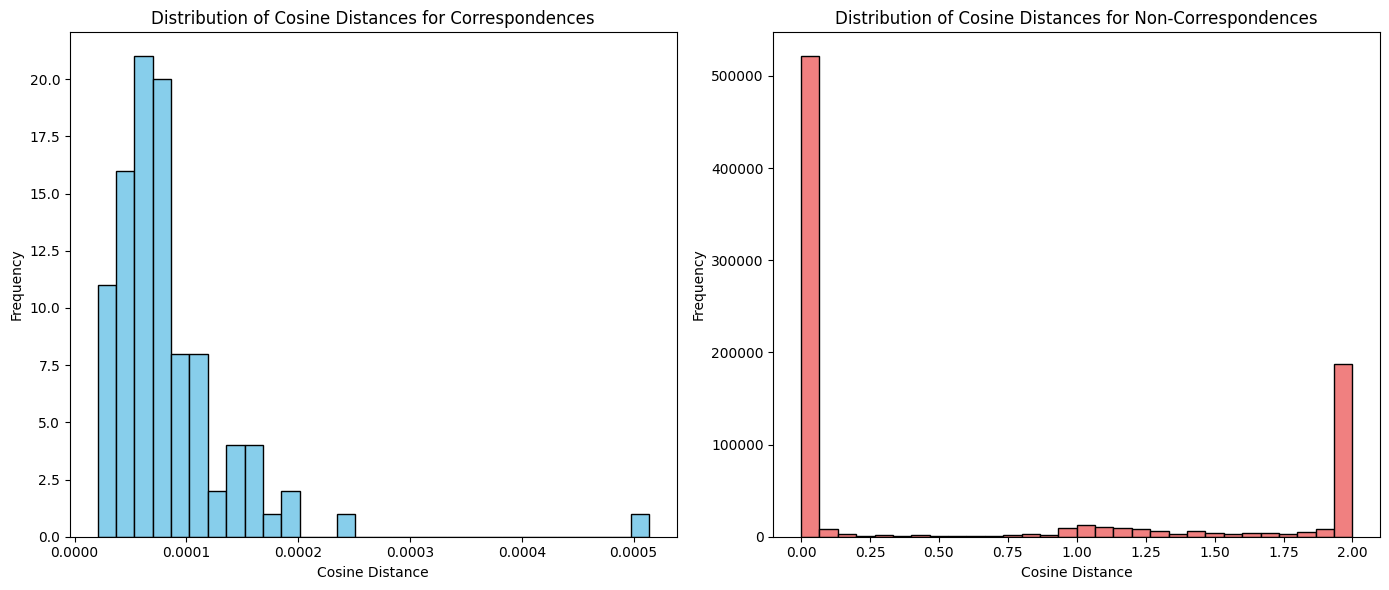

In [199]:
# 코사인 디스턴스 계산
src_np = src_occ_feats.numpy()
trg_np = -trg_occ_feats.numpy()

score_matrix = cosine_distances(src_np, trg_np)

# gt_corr에 해당하는 diagonal 부분의 값 추출
corr_indices_src = gt_corr[:, 0].numpy()
corr_indices_trg = gt_corr[:, 1].numpy()

# diagonal 부분의 score 분포 추출
diagonal_scores = score_matrix[corr_indices_src, corr_indices_trg]

# correspondence를 제외한 나머지 인덱스 구하기
all_indices_src = np.arange(src_occ_feats.size(0))
all_indices_trg = np.arange(trg_occ_feats.size(0))

non_corr_indices_src = np.setdiff1d(all_indices_src, corr_indices_src)
non_corr_indices_trg = np.setdiff1d(all_indices_trg, corr_indices_trg)

# correspondence가 아닌 점들에 대한 scores 추출
non_corr_scores = score_matrix[np.ix_(non_corr_indices_src, non_corr_indices_trg)].flatten()

# 시각화
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.hist(diagonal_scores, bins=30, color='skyblue', edgecolor='black')
plt.title('Distribution of Cosine Distances for Correspondences')
plt.xlabel('Cosine Distance')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
plt.hist(non_corr_scores, bins=30, color='lightcoral', edgecolor='black')
plt.title('Distribution of Cosine Distances for Non-Correspondences')
plt.xlabel('Cosine Distance')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

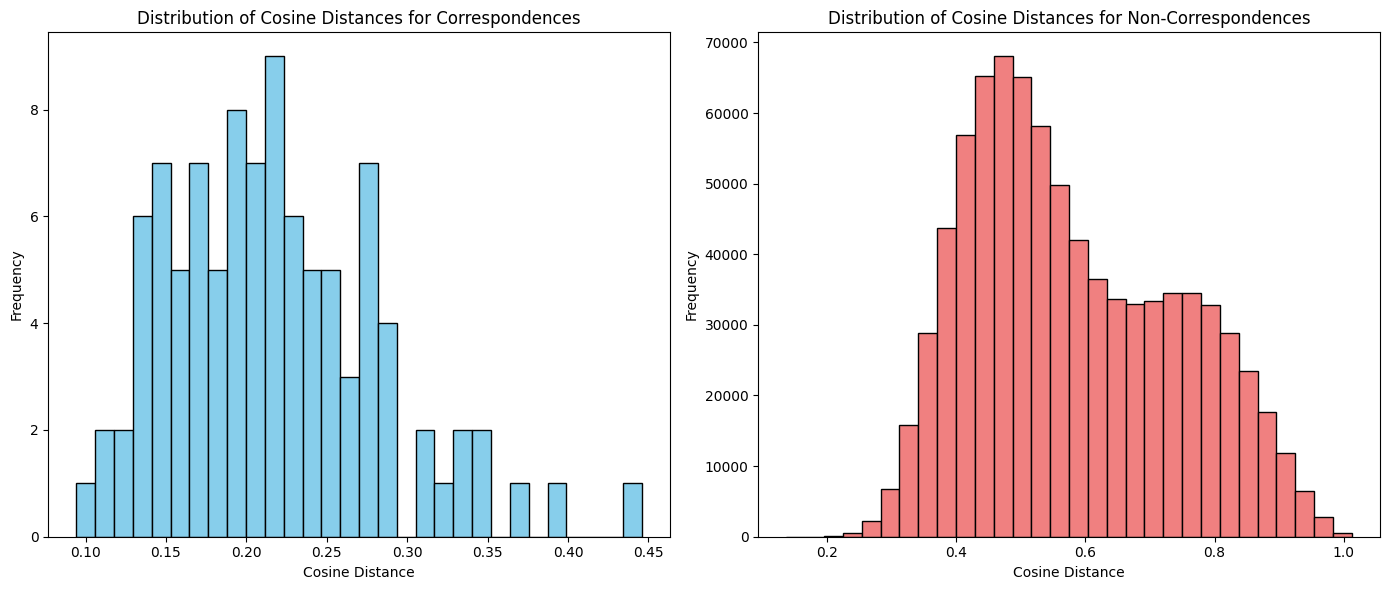

In [200]:
# 코사인 디스턴스 계산
src_np = src_shape_feats.numpy()
trg_np = trg_shape_feats.numpy()

score_matrix = cosine_distances(src_np, trg_np)

# gt_corr에 해당하는 diagonal 부분의 값 추출
corr_indices_src = gt_corr[:, 0].numpy()
corr_indices_trg = gt_corr[:, 1].numpy()

# diagonal 부분의 score 분포 추출
diagonal_scores = score_matrix[corr_indices_src, corr_indices_trg]

# correspondence를 제외한 나머지 인덱스 구하기
all_indices_src = np.arange(src_occ_feats.size(0))
all_indices_trg = np.arange(trg_occ_feats.size(0))

non_corr_indices_src = np.setdiff1d(all_indices_src, corr_indices_src)
non_corr_indices_trg = np.setdiff1d(all_indices_trg, corr_indices_trg)

# correspondence가 아닌 점들에 대한 scores 추출
non_corr_scores = score_matrix[np.ix_(non_corr_indices_src, non_corr_indices_trg)].flatten()

# 시각화
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.hist(diagonal_scores, bins=30, color='skyblue', edgecolor='black')
plt.title('Distribution of Cosine Distances for Correspondences')
plt.xlabel('Cosine Distance')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
plt.hist(non_corr_scores, bins=30, color='lightcoral', edgecolor='black')
plt.title('Distribution of Cosine Distances for Non-Correspondences')
plt.xlabel('Cosine Distance')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

# Shape Features

In [1]:
src = src_shape_feats.numpy()
trg = trg_shape_feats.numpy()
combined_features = np.concatenate((src, trg), axis=0)

# t-SNE 모델 생성 및 적용
tsne = TSNE(n_components=2, random_state=0)
features_2d = tsne.fit_transform(combined_features)

# 시각화를 위한 라벨 생성
labels = np.array([0] * len(src) + [1] * len(trg))

# correspondence 라벨 생성
corr_src_indices = gt_corr[:, 0].numpy()
corr_trg_indices = gt_corr[:, 1].numpy()

# 색상 맵핑
colors = np.array(['red'] * len(src) + ['blue'] * len(trg), dtype='object')
colors[corr_src_indices] = 'orange'
colors[len(src) + corr_trg_indices] = 'skyblue'

# 결과 시각화
plt.figure(figsize=(8, 6))

# 일반 점들을 먼저 그리기
non_corr_indices = np.setdiff1d(np.arange(len(src)), corr_src_indices)
non_corr_trg_indices = np.setdiff1d(np.arange(len(trg)), corr_trg_indices)

plt.scatter(features_2d[len(src) + corr_trg_indices, 0], features_2d[len(src) + corr_trg_indices, 1], c='skyblue', s=5, label='trg corr')
plt.scatter(features_2d[len(src) + non_corr_trg_indices, 0], features_2d[len(src) + non_corr_trg_indices, 1], c='blue', s=1, label='trg non-corr')
plt.scatter(features_2d[corr_src_indices, 0], features_2d[corr_src_indices, 1], c='orange', s=5, label='src corr')
plt.scatter(features_2d[non_corr_indices, 0], features_2d[non_corr_indices, 1], c='red', s=1, label='src non-corr')

plt.title('2D t-SNE of Combined Point Cloud Features with Correspondence')
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')

# 범례 추가
legend_elements = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='orange', markersize=5, label='Src Corr'),
                   plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='skyblue', markersize=5, label='Trg Corr'),
                   plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='red', markersize=5, label='Src Non-Corr'),
                   plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='blue', markersize=5, label='Trg Non-Corr')]

plt.legend(handles=legend_elements, title="Feature Set")
plt.show()

NameError: name 'src_shape_feats' is not defined

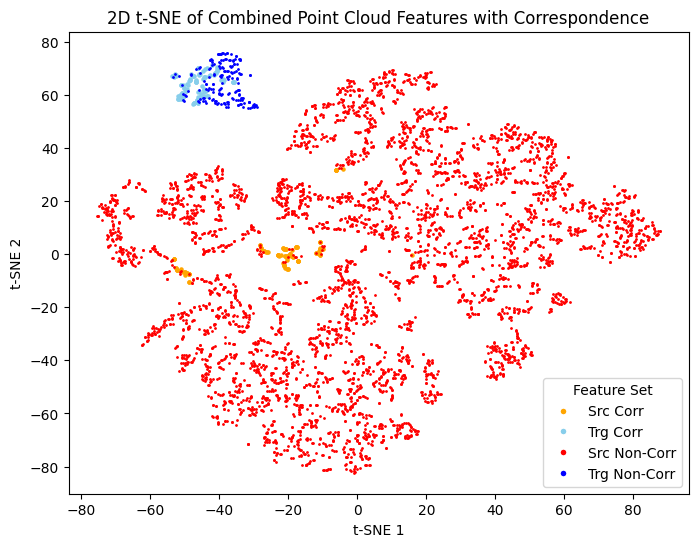

In [202]:
src = src_inv_feats_before.numpy()
trg = trg_inv_feats_before.numpy()
combined_features = np.concatenate((src, trg), axis=0)

# t-SNE 모델 생성 및 적용
tsne = TSNE(n_components=2, random_state=0)
features_2d = tsne.fit_transform(combined_features)

# 시각화를 위한 라벨 생성
labels = np.array([0] * len(src) + [1] * len(trg))

# correspondence 라벨 생성
corr_src_indices = gt_corr[:, 0].numpy()
corr_trg_indices = gt_corr[:, 1].numpy()

# 색상 맵핑
colors = np.array(['red'] * len(src) + ['blue'] * len(trg), dtype='object')
colors[corr_src_indices] = 'orange'
colors[len(src) + corr_trg_indices] = 'skyblue'

# 결과 시각화
plt.figure(figsize=(8, 6))

# 일반 점들을 먼저 그리기
non_corr_indices = np.setdiff1d(np.arange(len(src)), corr_src_indices)
non_corr_trg_indices = np.setdiff1d(np.arange(len(trg)), corr_trg_indices)

plt.scatter(features_2d[len(src) + corr_trg_indices, 0], features_2d[len(src) + corr_trg_indices, 1], c='skyblue', s=5, label='trg corr')
plt.scatter(features_2d[len(src) + non_corr_trg_indices, 0], features_2d[len(src) + non_corr_trg_indices, 1], c='blue', s=1, label='trg non-corr')
plt.scatter(features_2d[corr_src_indices, 0], features_2d[corr_src_indices, 1], c='orange', s=5, label='src corr')
plt.scatter(features_2d[non_corr_indices, 0], features_2d[non_corr_indices, 1], c='red', s=1, label='src non-corr')

plt.title('2D t-SNE of Combined Point Cloud Features with Correspondence')
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')

# 범례 추가
legend_elements = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='orange', markersize=5, label='Src Corr'),
                   plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='skyblue', markersize=5, label='Trg Corr'),
                   plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='red', markersize=5, label='Src Non-Corr'),
                   plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='blue', markersize=5, label='Trg Non-Corr')]

plt.legend(handles=legend_elements, title="Feature Set")
plt.show()

# Occupancy Features

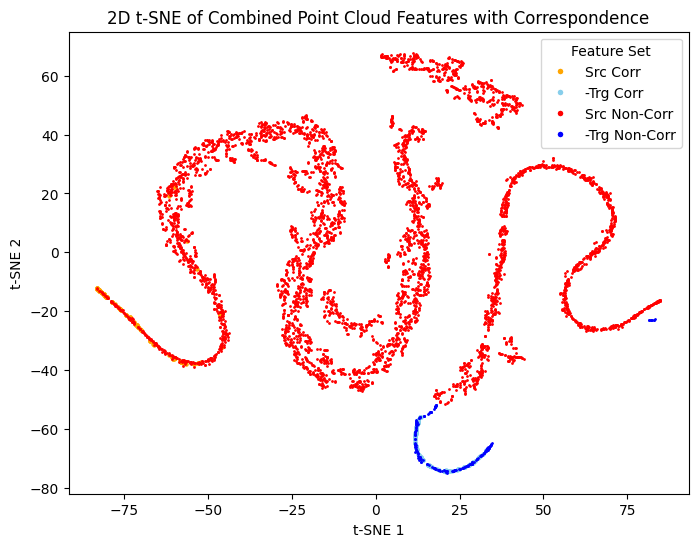

In [203]:
src = src_occ_feats.numpy()
trg = -trg_occ_feats.numpy()
combined_features = np.concatenate((src, trg), axis=0)

# t-SNE 모델 생성 및 적용
tsne = TSNE(n_components=2, random_state=0)
features_2d = tsne.fit_transform(combined_features)

# 시각화를 위한 라벨 생성
labels = np.array([0] * len(src) + [1] * len(trg))

# correspondence 라벨 생성
corr_src_indices = gt_corr[:, 0].numpy()
corr_trg_indices = gt_corr[:, 1].numpy()

# 색상 맵핑
colors = np.array(['red'] * len(src) + ['blue'] * len(trg), dtype='object')
colors[corr_src_indices] = 'orange'
colors[len(src) + corr_trg_indices] = 'skyblue'

# 결과 시각화
plt.figure(figsize=(8, 6))

# 일반 점들을 먼저 그리기
non_corr_indices = np.setdiff1d(np.arange(len(src)), corr_src_indices)
non_corr_trg_indices = np.setdiff1d(np.arange(len(trg)), corr_trg_indices)

plt.scatter(features_2d[len(src) + corr_trg_indices, 0], features_2d[len(src) + corr_trg_indices, 1], c='skyblue', s=5, label='trg corr')
plt.scatter(features_2d[len(src) + non_corr_trg_indices, 0], features_2d[len(src) + non_corr_trg_indices, 1], c='blue', s=1, label='trg non-corr')
plt.scatter(features_2d[corr_src_indices, 0], features_2d[corr_src_indices, 1], c='orange', s=5, label='src corr')
plt.scatter(features_2d[non_corr_indices, 0], features_2d[non_corr_indices, 1], c='red', s=1, label='src non-corr')

plt.title('2D t-SNE of Combined Point Cloud Features with Correspondence')
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')

# 범례 추가
legend_elements = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='orange', markersize=5, label='Src Corr'),
                   plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='skyblue', markersize=5, label='-Trg Corr'),
                   plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='red', markersize=5, label='Src Non-Corr'),
                   plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='blue', markersize=5, label='-Trg Non-Corr')]

plt.legend(handles=legend_elements, title="Feature Set")
plt.show()

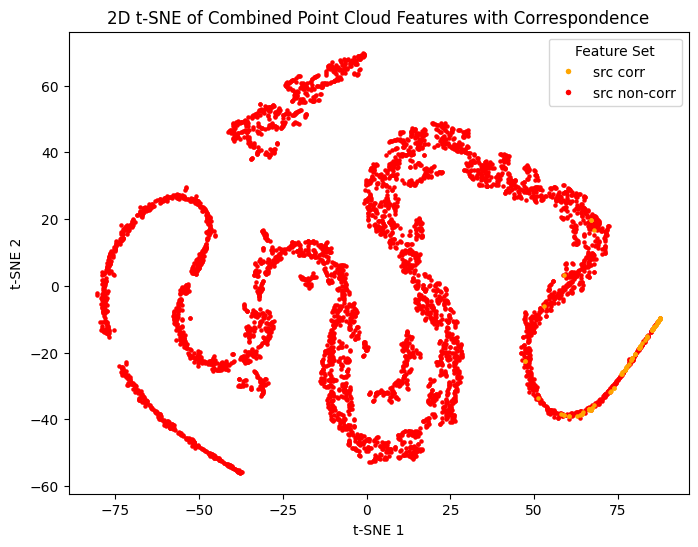

In [204]:
src = src_occ_feats.numpy()

# t-SNE 모델 생성 및 적용
tsne = TSNE(n_components=2, random_state=0)
features_2d = tsne.fit_transform(src)

# 시각화를 위한 라벨 생성
labels = np.array([0] * len(src))

# correspondence 라벨 생성
corr_src_indices = gt_corr[:, 0].numpy()

# 색상 맵핑
colors = np.array(['red'] * len(src), dtype='object')
colors[corr_src_indices] = 'orange'

# 결과 시각화
plt.figure(figsize=(8, 6))

# 일반 점들을 먼저 그리기
non_corr_indices = np.setdiff1d(np.arange(len(src)), corr_src_indices)
plt.scatter(features_2d[non_corr_indices, 0], features_2d[non_corr_indices, 1], c='red', s=5, label='src non-corr')

# 주황색과 하늘색 점들을 크게 그리기
plt.scatter(features_2d[corr_src_indices, 0], features_2d[corr_src_indices, 1], c='orange', s=5, label='src corr')

plt.title('2D t-SNE of Combined Point Cloud Features with Correspondence')
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')

# 범례 추가
legend_elements = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='orange', markersize=5, label='src corr'),
                   plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='red', markersize=5, label='src non-corr'),]

plt.legend(handles=legend_elements, title="Feature Set")
plt.show()

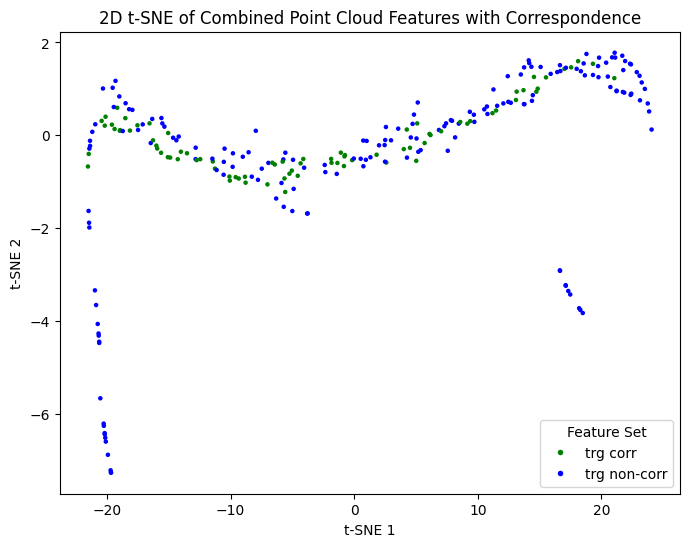

In [205]:
trg = -trg_occ_feats.numpy()

# t-SNE 모델 생성 및 적용
tsne = TSNE(n_components=2, random_state=0)
features_2d = tsne.fit_transform(trg)


# 시각화를 위한 라벨 생성
labels = np.array([0]*len(trg))

# correspondence 라벨 생성
corr_src_indices = gt_corr[:, 1].numpy()

# 색상 맵핑
colors = np.array(['blue'] * len(trg), dtype='object')
colors[corr_src_indices] = 'green'

# 결과 시각화
plt.figure(figsize=(8, 6))
scatter = plt.scatter(features_2d[:, 0], features_2d[:, 1], c=colors, s=5)

plt.title('2D t-SNE of Combined Point Cloud Features with Correspondence')
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')

# 범례 추가
legend_elements = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='green', markersize=5, label='trg corr'),
                   plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='blue', markersize=5, label='trg non-corr')]

plt.legend(handles=legend_elements, title="Feature Set")
plt.show()

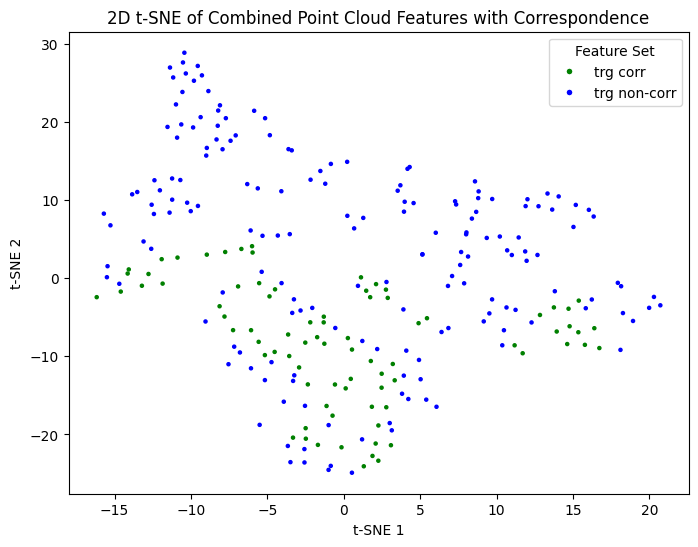

In [206]:
trg = trg_shape_feats.numpy()

# t-SNE 모델 생성 및 적용
tsne = TSNE(n_components=2, random_state=0)
features_2d = tsne.fit_transform(trg)


# 시각화를 위한 라벨 생성
labels = np.array([0]*len(trg))

# correspondence 라벨 생성
corr_src_indices = gt_corr[:, 1].numpy()

# 색상 맵핑
colors = np.array(['blue'] * len(trg), dtype='object')
colors[corr_src_indices] = 'green'

# 결과 시각화
plt.figure(figsize=(8, 6))
scatter = plt.scatter(features_2d[:, 0], features_2d[:, 1], c=colors, s=5)

plt.title('2D t-SNE of Combined Point Cloud Features with Correspondence')
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')

# 범례 추가
legend_elements = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='green', markersize=5, label='trg corr'),
                   plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='blue', markersize=5, label='trg non-corr')]

plt.legend(handles=legend_elements, title="Feature Set")
plt.show()